<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_061_knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 61/365 — K-Nearest Neighbors (KNN)

KNN classifies a new point by looking at the `K` closest training examples and letting them vote.

If `K=5` and the nearest labels are:

`Churn, Churn, Stay, Churn, Stay`

then the prediction is **Churn**.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report


## 1. Load a real dataset


In [2]:
data=load_breast_cancer(as_frame=True)
X=data.data
y=data.target

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.25,random_state=42,stratify=y
)

print("Dataset shape:",X.shape)
print("Classes:",data.target_names)


Dataset shape: (569, 30)
Classes: ['malignant' 'benign']


## 2. Why scaling matters

KNN uses distance.

If one feature ranges from `0–1` and another from `0–100000`, the second can dominate distance.

So we use:

`StandardScaler → KNN`


In [3]:
model=Pipeline([
    ("scaler",StandardScaler()),
    ("knn",KNeighborsClassifier(n_neighbors=5))
])

model.fit(X_train,y_train)
pred=model.predict(X_test)

print("Test Accuracy:",round(accuracy_score(y_test,pred),3))
print(classification_report(
    y_test,pred,
    target_names=data.target_names,
    digits=3
))


Test Accuracy: 0.979
              precision    recall  f1-score   support

   malignant      1.000     0.943     0.971        53
      benign      0.968     1.000     0.984        90

    accuracy                          0.979       143
   macro avg      0.984     0.972     0.977       143
weighted avg      0.980     0.979     0.979       143



## 3. How does K affect performance?


In [4]:
k_values=list(range(1,31,2))
scores=[]

for k in k_values:
    m=Pipeline([
        ("scaler",StandardScaler()),
        ("knn",KNeighborsClassifier(n_neighbors=k))
    ])
    m.fit(X_train,y_train)
    scores.append(accuracy_score(y_test,m.predict(X_test)))

results=pd.DataFrame({
    "K":k_values,
    "Test Accuracy":scores
})

display(results.round(3))


,K,Test Accuracy
0,1,0.951
1,3,0.972
2,5,0.979
3,7,0.979
4,9,0.965
5,11,0.972
6,13,0.958
7,15,0.958
8,17,0.951
9,19,0.951


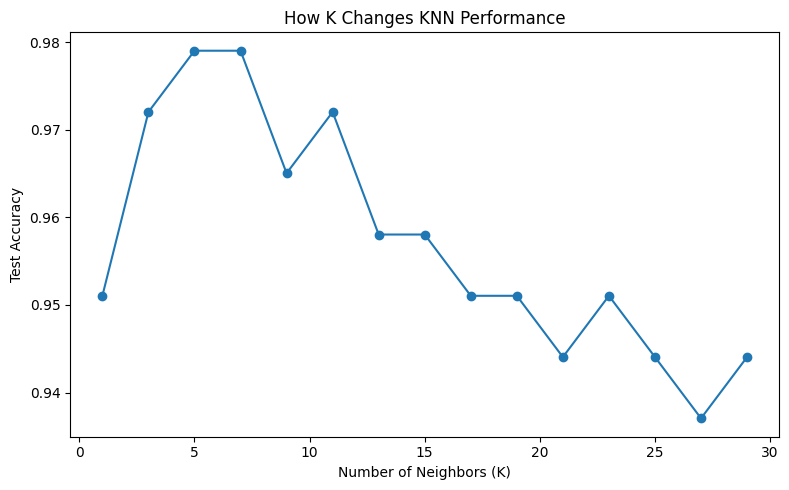

In [5]:
plt.figure(figsize=(8,5))
plt.plot(results["K"],results["Test Accuracy"],marker="o")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Test Accuracy")
plt.title("How K Changes KNN Performance")
plt.tight_layout()
plt.show()


## Enterprise intuition

KNN is useful when **similar cases tend to behave similarly**.

Examples:
- customer churn
- fraud pattern matching
- recommendation systems
- support-ticket matching

But it also has limitations:
- prediction can be slow on large datasets
- it stores the training data
- scaling matters
- high-dimensional data makes distance less meaningful

Small `K` can overfit. Large `K` can underfit.

> **KNN asks: which known examples are most similar to this new one?**


## References

- https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
- https://scikit-learn.org/stable/modules/neighbors.html
- https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
